In [1]:
from matplotlib import pyplot as plt
from echospec.experiments.spectroscopy_vs_amplitude import AmplitudeSweepSpectroscopy
from echospec.experiments.spectrsocopy_vs_amplitude_vs_cutoff import OptionsSpectroscopy2d
from echospec.utils.parameters import Parameters
from echospec.utils.units import Units as u

import numpy as np
import json
# from dataclasses import asdict
print(plt.style.available)
from echospec.figures import FigureVariant, apply_figure_style, save_figure

VARIANT = FigureVariant.PAPER
apply_figure_style(VARIANT)


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


Amplitude sweep:   0%|          | 0/101 [00:00<?, ?Ω/s]

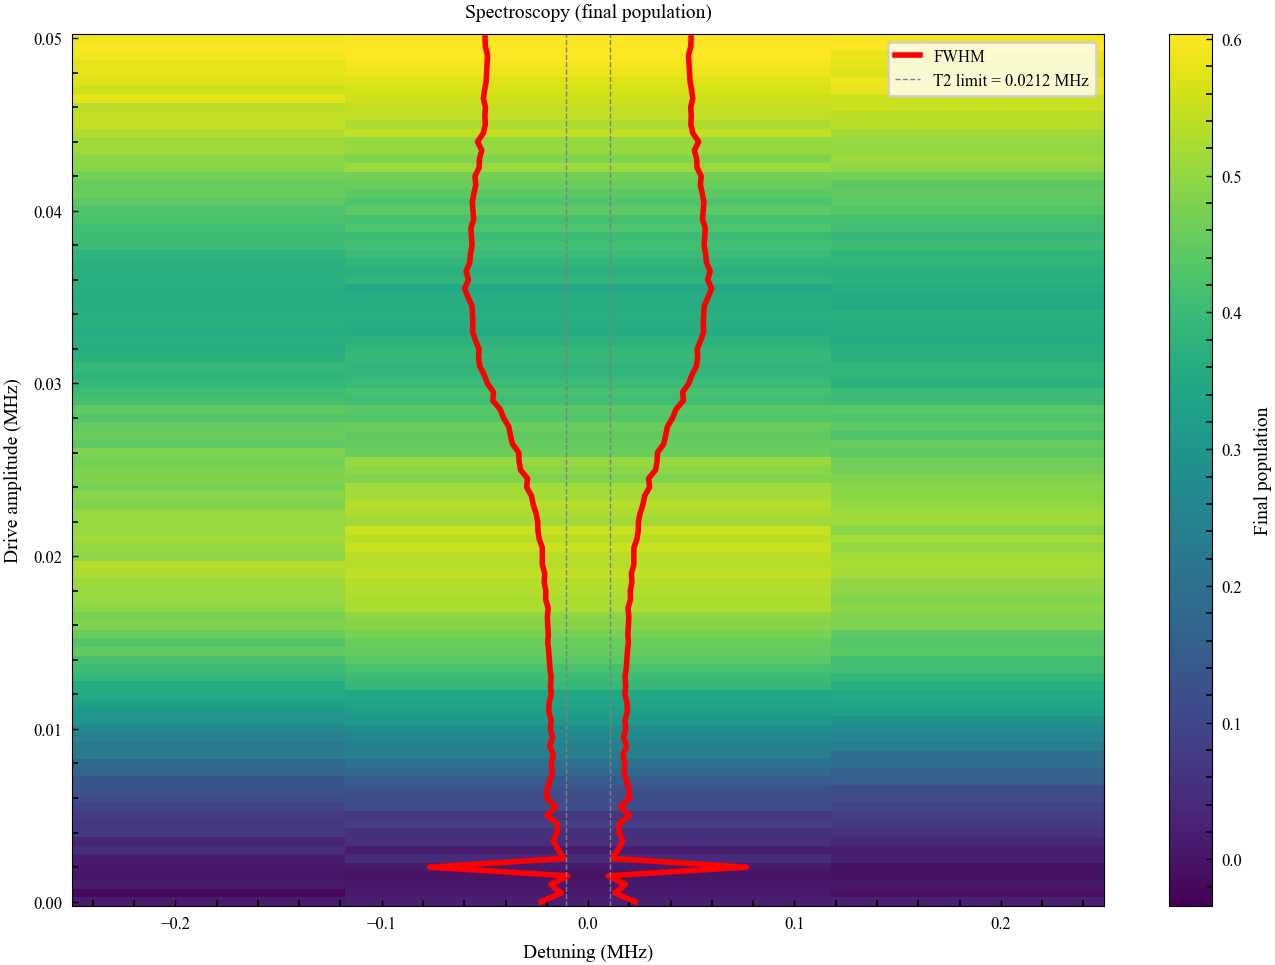

In [2]:

options = OptionsSpectroscopy2d(plot=True)
options.num_time_points = 1000
options.plot = True
options.noise = 0.02


params = Parameters()
params.eco_pulse = False
params.pulse_length = 30*u.us
params.cutoff = 0.9999#2e-4


detunings = np.linspace(-0.25, 0.25, 101)*2*np.pi*u.MHz
amplitudes = np.linspace(0, 0.05, 101)*2*np.pi*u.MHz

spectroscopy = AmplitudeSweepSpectroscopy(
    amplitudes=amplitudes,
    detunings=detunings,
    params=params,
    options=options
)

results = spectroscopy.run()

amplitudes = results.amplitudes 
detunings = results.detunings
states = results.populations

np.savez(
    'data/2d_sweep/const.npz',
    amplitudes=amplitudes,
    detunings=detunings,
    states=states,
    # params=asdict(params),
    )


plt.pcolormesh(detunings/params.T2_limit/2/np.pi, amplitudes/u.MHz/2/np.pi, states, shading='auto', cmap='viridis')




In [3]:
from pathlib import Path
params = Parameters()


def load_2d_spec_data(file_path):
    """
    Load 2D spectroscopy data from a JSON file.
    
    Parameters:
    -----------
    file_path : str
        Path to the JSON file containing the spectroscopy data
        
    Returns:
    --------
    tuple
        (detunings, amplitudes, states) as lists from the JSON file
    """
    
    folder_path = Path("/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/data/2025-09-17/")
    
    file_path = folder_path / file_path
    with open(file_path, 'r') as f:
        data = f.read()
    params = json.loads(data)
    
    states = params['measured_data']['states']
    sweep_parameters = params['sweep_parameters']
    detunings = np.array(sweep_parameters['detuning'])
    amplitudes = sweep_parameters['amplitudes']
    
    return detunings/1e6, amplitudes, states,[]



def load_2d_spec_sim(file_name):
    folder_path = Path("/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/data/2d_sweep/")
    file_path = folder_path / file_name
    data = np.load(file_path, allow_pickle=True)
    
    
    detunings = data['detunings']
    amplitudes = data['amplitudes']
    states = data['states']
    
    return detunings/1e6/2/np.pi, amplitudes/2/np.pi/1e6, states
    
# file_name1 = 'lorentzian-echo-False-2d-200.0-us-0.9999.json'
# file_name2 = 'lorentzian-echo-False-2d-50.0-us-0.0002.json'
# file_name3 = 'lorentzian-echo-True-2d-50.0-us-0.0002.json'

# detunings1, amplitudes1, states1 = load_2d_spec_data(file_name1)
# detunings2, amplitudes2, states2 = load_2d_spec_data(file_name2)
# detunings3, amplitudes3, states3 = load_2d_spec_data(file_name3)


detunings1, amplitudes1, states1 = load_2d_spec_sim('const.npz')
detunings2, amplitudes2, states2 = load_2d_spec_sim('lorentzian.npz')
detunings3, amplitudes3, states3 = load_2d_spec_sim('echo_lorentzian.npz')


FileNotFoundError: [Errno 2] No such file or directory: 'square_measurement_pulse_transparent.png'

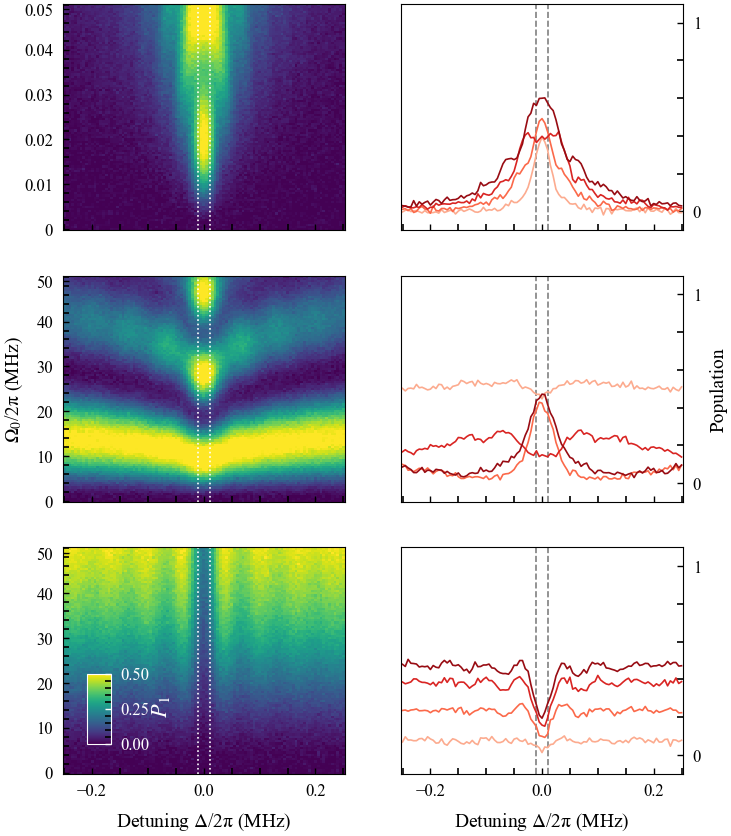

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# ------------------------------------------------------------------
# Figure & axes
# ------------------------------------------------------------------
fig, axs = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(4, 5),
    sharex=True,
)

# ------------------------------------------------------------------
# Data containers
# ------------------------------------------------------------------
detunings = [detunings1, detunings2, detunings3]
amplitudes = [amplitudes1, amplitudes2, amplitudes3]
states = [states1, states2, states3]

IDX = [25, 50, 75, 99]
VMIN, VMAX = 0.0, 0.5
CMAP = "viridis"

# ------------------------------------------------------------------
# Left column: 2D color plots
# ------------------------------------------------------------------
images = []
for row, (d, a, s) in enumerate(zip(detunings, amplitudes, states)):
    im = axs[row, 0].pcolormesh(
        d, a, s,
        shading="auto",
        cmap=CMAP,
        vmin=VMIN,
        vmax=VMAX,
    )
    images.append(im)

# ------------------------------------------------------------------
# Colorbar (top, horizontal)
# ------------------------------------------------------------------
cax = fig.add_axes((0.155, 0.14, 0.03, 0.07))
cbar = fig.colorbar(images[1], cax=cax, orientation="vertical")
cbar.set_label(r" $P_1$", labelpad=0.0, fontsize=8,color= 'white')
cbar.ax.tick_params(colors='white')
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("top")
cbar.outline.set_edgecolor('white')
cbar.ax.yaxis.set_tick_params(color='white')
for spine in cbar.ax.spines.values():
    spine.set_edgecolor('white')

# ------------------------------------------------------------------
# Y ticks
# ------------------------------------------------------------------
axs[0, 0].set_yticks([0, 0.01,0.02,0.03,0.04, 0.049], labels=["0","0.01","0.02","0.03","0.04", "0.05"])

for ax in axs[1:, 0]:
    ax.set_yticks([0, 10,20,30,40, 49], labels=["0", "10", "20", "30", "40", "50"])

for ax in axs[:, 1]:
    ax.set_yticks([0, 1], labels=["0", "1"])
    ax.set_ylim(-0.1, 1.1)

# ------------------------------------------------------------------
# Vertical reference lines
# ------------------------------------------------------------------
for ax_l, ax_r in axs:
    ax_l.axvline(params.T2_limit/2/1e6,  color="white", linestyle=":",  linewidth=0.6)
    ax_l.axvline(-params.T2_limit/2/1e6, color="white", linestyle=":",  linewidth=0.6)
    ax_r.axvline(params.T2_limit/2/1e6,  color="gray",  linestyle="--", linewidth=0.6)
    ax_r.axvline(-params.T2_limit/2/1e6, color="gray",  linestyle="--", linewidth=0.6)
    
    
    
cmap = plt.cm.Reds
colors = cmap(np.linspace(0.3, 0.9, len(IDX)))  # dark → light blue

for c, i in zip(colors, IDX):
    axs[0, 1].plot(detunings1, states1[i], color=c, label=f"{amplitudes1[i]:.2f}", linewidth=0.6)
    axs[1, 1].plot(detunings2, states2[i], color=c, label=f"{amplitudes2[i]:.0f}", linewidth=0.6)
    axs[2, 1].plot(detunings3, states3[i], color=c, label=f"{amplitudes3[i]:.0f}", linewidth=0.6)
# ------------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------------
for row in range(3):
    axs[1, 0].set_ylabel(r"$\Omega_0$/2π (MHz)")
    axs[1, 1].set_ylabel("Population", labelpad=3.)
    axs[row, 1].yaxis.set_label_position("right")
    axs[row, 1].yaxis.tick_right()

for ax in axs[2, :]:
    ax.set_xlabel(r"Detuning $\Delta$/2π (MHz)")

# ------------------------------------------------------------------
# Pulse images (left column)
# ------------------------------------------------------------------
image_files = [
    "square_measurement_pulse_transparent.png",
    "lorentzian_pulse_transparent.png",
    "lorentzian_flip_pulse_transparent.png",
]

for row, fname in enumerate(image_files):
    img = mpimg.imread(fname)
    imagebox = OffsetImage(img, zoom=0.3)
    ab = AnnotationBbox(
        imagebox,
        (0.22, 0.75),
        xycoords="axes fraction",
        frameon=False,
    )
    axs[row, 0].add_artist(ab)
    
    
# ------------------------------------------------------------------
# Panel labels
# ------------------------------------------------------------------
labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
for idx, (ax, lab) in enumerate(zip(axs.flat, labels)):
    # Left column (indices 0, 2, 4) use white text
    color = "white" if idx % 2 == 0 else "black"
    ax.annotate(
        lab,
        xy=(0.05, 0.85),
        xycoords="axes fraction",
        ha="left",
        va="bottom",
        fontsize=10,
        color=color,
    )
import matplotlib.transforms as transforms

# --- after you define `colors` (and IDX) ---
tick_x = 0.955 # slightly outside the right spine of the LEFT axes
tick_marker = '_'      # small horizontal tick
tick_ms = 8            # marker size
tick_mew = 1.2        # marker line width

for row, (axL, amps) in enumerate(zip(axs[:, 0], amplitudes)):
    # y-positions (amplitudes) that correspond to the slices you plotted on the right
    yvals = np.asarray(amps)[IDX]

    # x in axes coords, y in data coords
    trans = transforms.blended_transform_factory(axL.transAxes, axL.transData)

    for c, y in zip(colors, yvals):
        axL.plot(
            [tick_x], [y],
            transform=trans,
            marker=tick_marker,
            markersize=tick_ms,
            markeredgewidth=tick_mew,
            color=c,
            linestyle="None",
            clip_on=False,   # allow drawing outside the axes
            zorder=10
        )



# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------
save_figure(plt.gcf(), "2d_spectroscopy_comparison", variant=VARIANT, formats=("png",))
# plt.close()
